In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
plt.rcParams["font.size"] = 18
plt.rcParams['figure.dpi'] = 600
plt.rcParams['figure.figsize'] = (10, 10)

In [31]:
donor_df = pd.read_csv("/root/capsule/data/Supplemental Tables/Supplemental Table 8.csv", index_col = 0)

In [32]:
neuropath_df = pd.read_csv("/root/capsule/data/Supplemental Tables/Supplemental Table 7.csv", index_col = 0)

In [33]:
donor_df = donor_df.merge(neuropath_df,left_index = True, right_index = True)

In [34]:
donor_df

,Primary Study Name,Secondary Study Name,Age at Death,Sex,Race (choice=White),Race (choice=Black/ African American),Race (choice=Asian),Race (choice=American Indian/ Alaska Native),Race (choice=Native Hawaiian or Pacific Islander),Race (choice=Unknown or unreported),...,number of AT8 positive cells per area,percent AT8 positive area,percent pTDP43 positive area,percent 6e10 dense core plaque area,percent 6e10 positive area,percent of 6e10 positive objects colocalized with Iba1 positive objects,tangle_per_tissue_area_um^2,CPS,CPS_AT8,CPS_6E10
H19.33.004,ACT,NaN,80,Female,Checked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,...,0.000000e+00,0.000001,0.000074,0.000802,0.000000,0.000000,1.245057e-07,0.000000,0.000000,0.000000
H20.33.001,ACT,NaN,82,Male,Checked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,...,3.260000e-07,0.066747,0.000451,0.000000,0.000000,0.000000,7.091258e-07,0.577213,0.618921,0.349652
H20.33.005,ACT,NaN,99,Female,Checked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,...,9.260000e-08,0.004159,0.000328,0.010122,0.079647,34.337300,2.374795e-07,0.702125,0.476388,0.738349
H20.33.008,ACT,NaN,92,Female,Checked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,...,3.240000e-07,0.558316,0.000372,0.006540,1.113280,25.000000,1.305516e-06,0.961588,0.823632,0.913234
H20.33.011,ACT,NaN,93,Female,Checked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,...,2.780000e-06,0.282541,0.000012,0.001428,2.419150,7.328920,5.672007e-07,0.972877,0.820284,0.972102
H20.33.012,ACT,NaN,91,Female,Checked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,...,3.170000e-08,0.001723,0.000048,0.000000,0.000000,0.000000,7.745441e-07,0.261753,0.264122,0.195115
H20.33.013,ACT,NaN,94,Male,Checked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,...,8.140000e-07,0.013461,0.000060,0.000000,0.074065,41.573000,4.336356e-07,0.798131,0.626150,0.732119
H20.33.015,ACT,NaN,88,Male,Checked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,...,3.770000e-07,0.015323,0.000023,0.000000,0.008575,45.454500,3.133815e-07,0.675589,0.566821,0.585716
H20.33.016,ADRC Clinical Core,NaN,93,Female,Checked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,...,5.170000e-08,0.008250,0.000081,0.004417,0.571832,8.108110,2.736619e-07,0.814145,0.529276,0.878570
H20.33.017,ADRC Clinical Core,NaN,69,Male,Checked,Unchecked,Unchecked,Unchecked,Unchecked,Unchecked,...,1.230000e-06,4.135247,0.000130,0.001143,0.264275,46.811100,9.270124e-07,0.981598,0.979507,0.842205


In [43]:
data  = donor_df.sort_values("CPS")[['Overall AD neuropathological Change', 'Braak', 'Thal', 'percent AT8 positive area', 'percent 6e10 positive area', 'CPS_AT8', 'CPS_6E10']].rename(columns = {'Overall AD neuropathological Change':'ADNC',  'percent AT8 positive area':"AT8", 'percent 6e10 positive area': "6E10"})

In [44]:
adnc_order = ["Not AD", "Low", "Intermediate", "High"]
braak_order = ["Braak 0", "Braak II", "Braak III", "Braak IV", "Braak V", "Braak VI"]
thal_order = ["Thal 0", "Thal 1", "Thal 2", "Thal 3", "Thal 4", "Thal 5"]

data["ADNC"] = data["ADNC"].astype("category").cat.reorder_categories(adnc_order, ordered=True).cat.codes
data["Braak"] = data['Braak'].astype("category").cat.reorder_categories(braak_order, ordered = True).cat.codes
data["Thal"] = data["Thal"].astype("category").cat.reorder_categories(thal_order, ordered = True).cat.codes

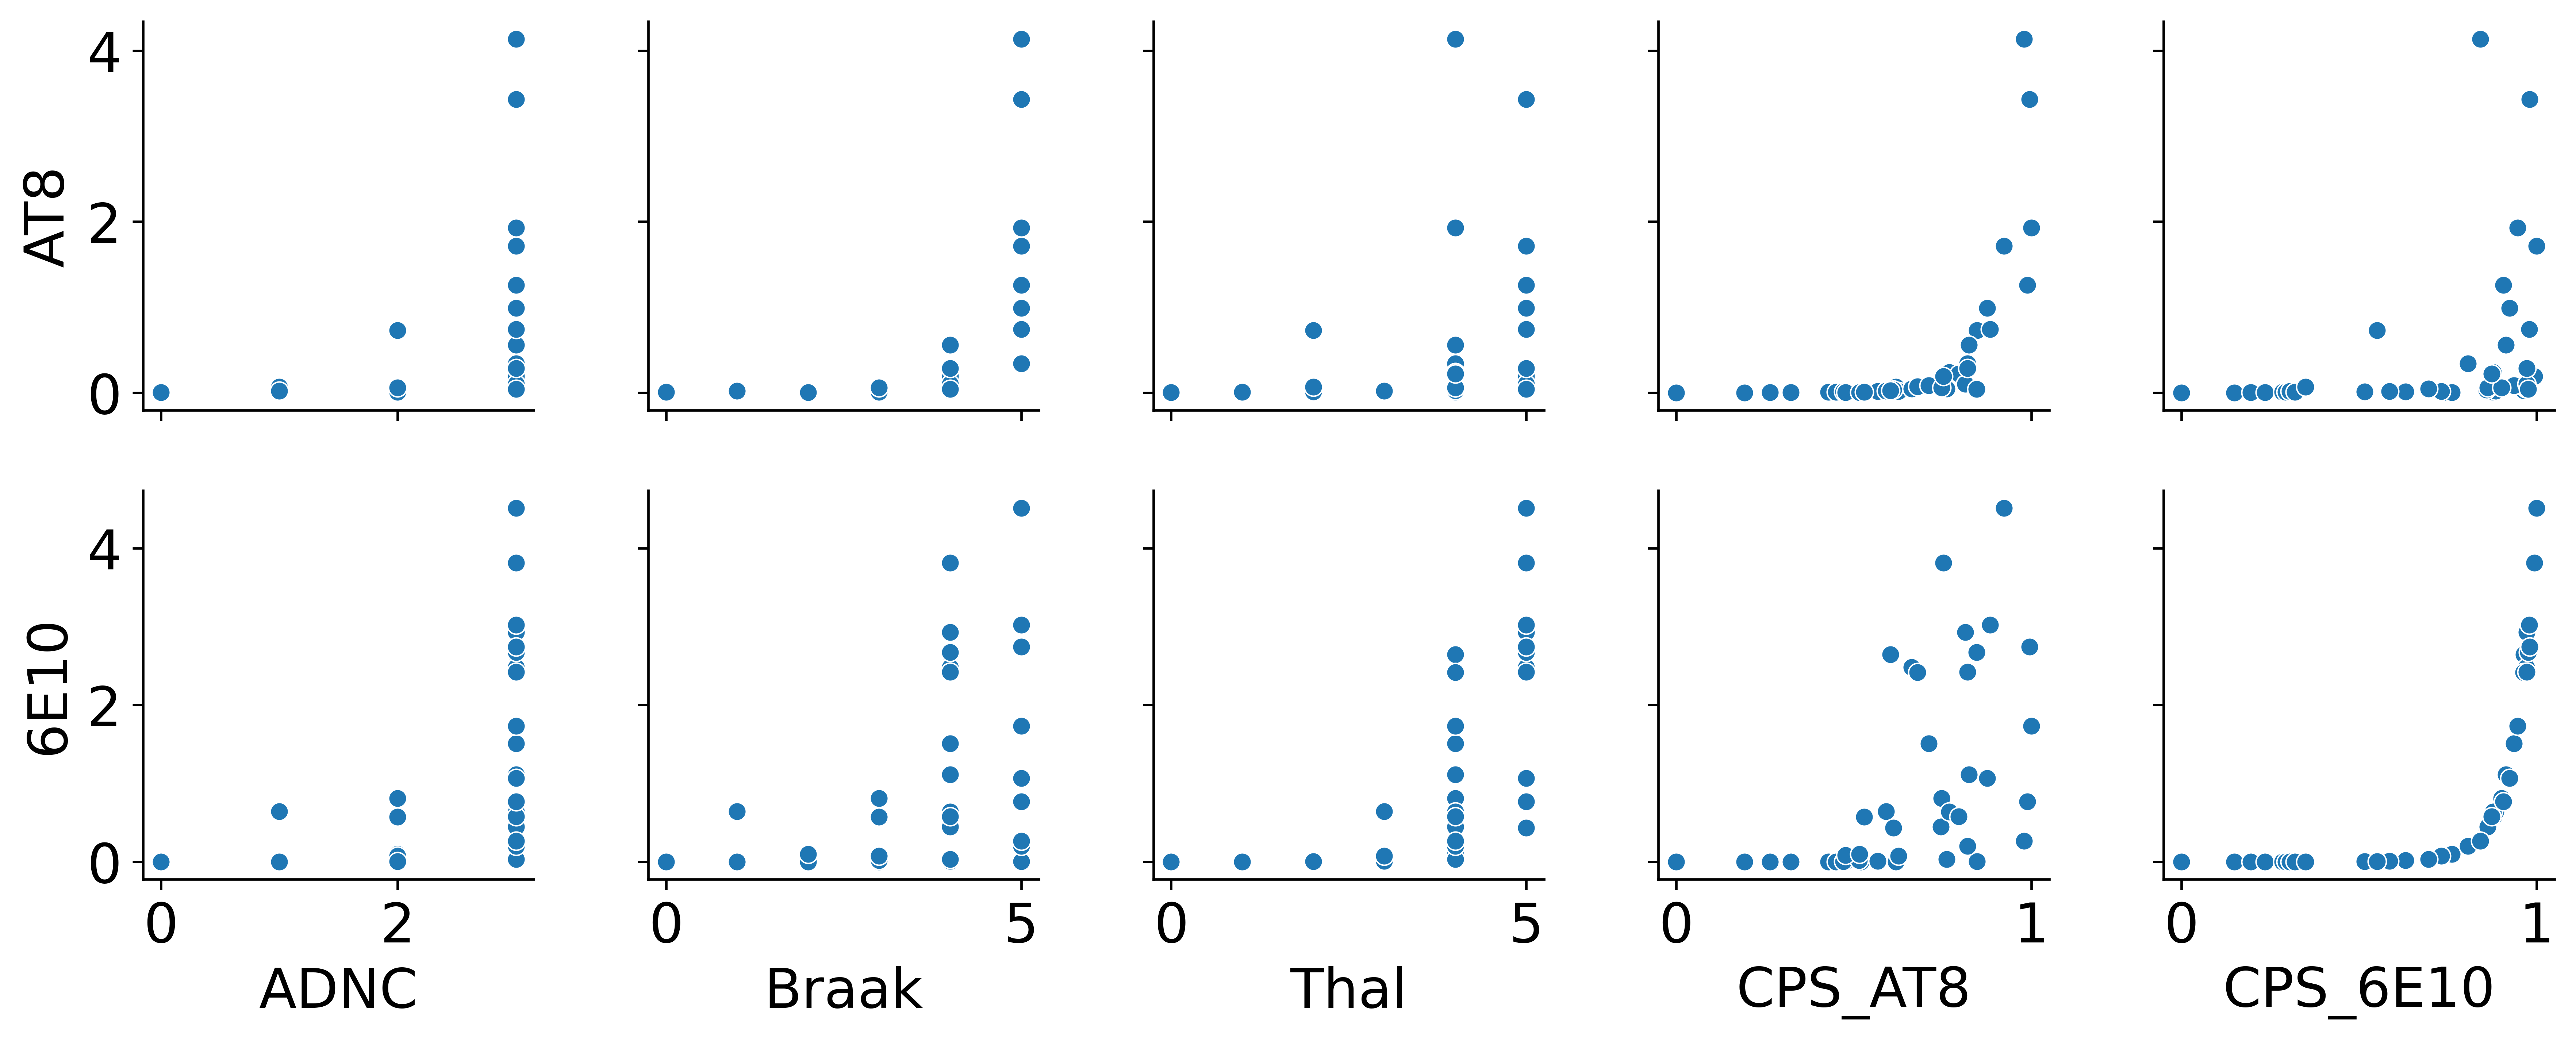

In [46]:
g = sns.PairGrid(data, x_vars = ['ADNC', 'Braak', 'Thal','CPS_AT8', 'CPS_6E10'], y_vars = ['AT8', '6E10'])
g.map(sns.scatterplot)

In [8]:
data["ADNC"]

H19.33.004          Not AD
H21.33.004          Not AD
H20.33.012             Low
H21.33.003          Not AD
H21.33.019             Low
H21.33.001             Low
H21.33.038             Low
H21.33.028             Low
H21.33.032             Low
H20.33.001             Low
H20.33.027    Intermediate
H20.33.015    Intermediate
H20.33.005    Intermediate
H20.33.019    Intermediate
H20.33.013    Intermediate
H20.33.016    Intermediate
H21.33.022    Intermediate
H21.33.018             Low
H21.33.035            High
H20.33.039            High
H21.33.026            High
H20.33.029            High
H21.33.027            High
H21.33.013            High
H20.33.025            High
H20.33.031            High
H20.33.040    Intermediate
H21.33.039            High
H20.33.028            High
H21.33.033            High
H20.33.008            High
H20.33.036            High
H20.33.011            High
H20.33.046            High
H20.33.037            High
H20.33.017            High
H20.33.033            High
H

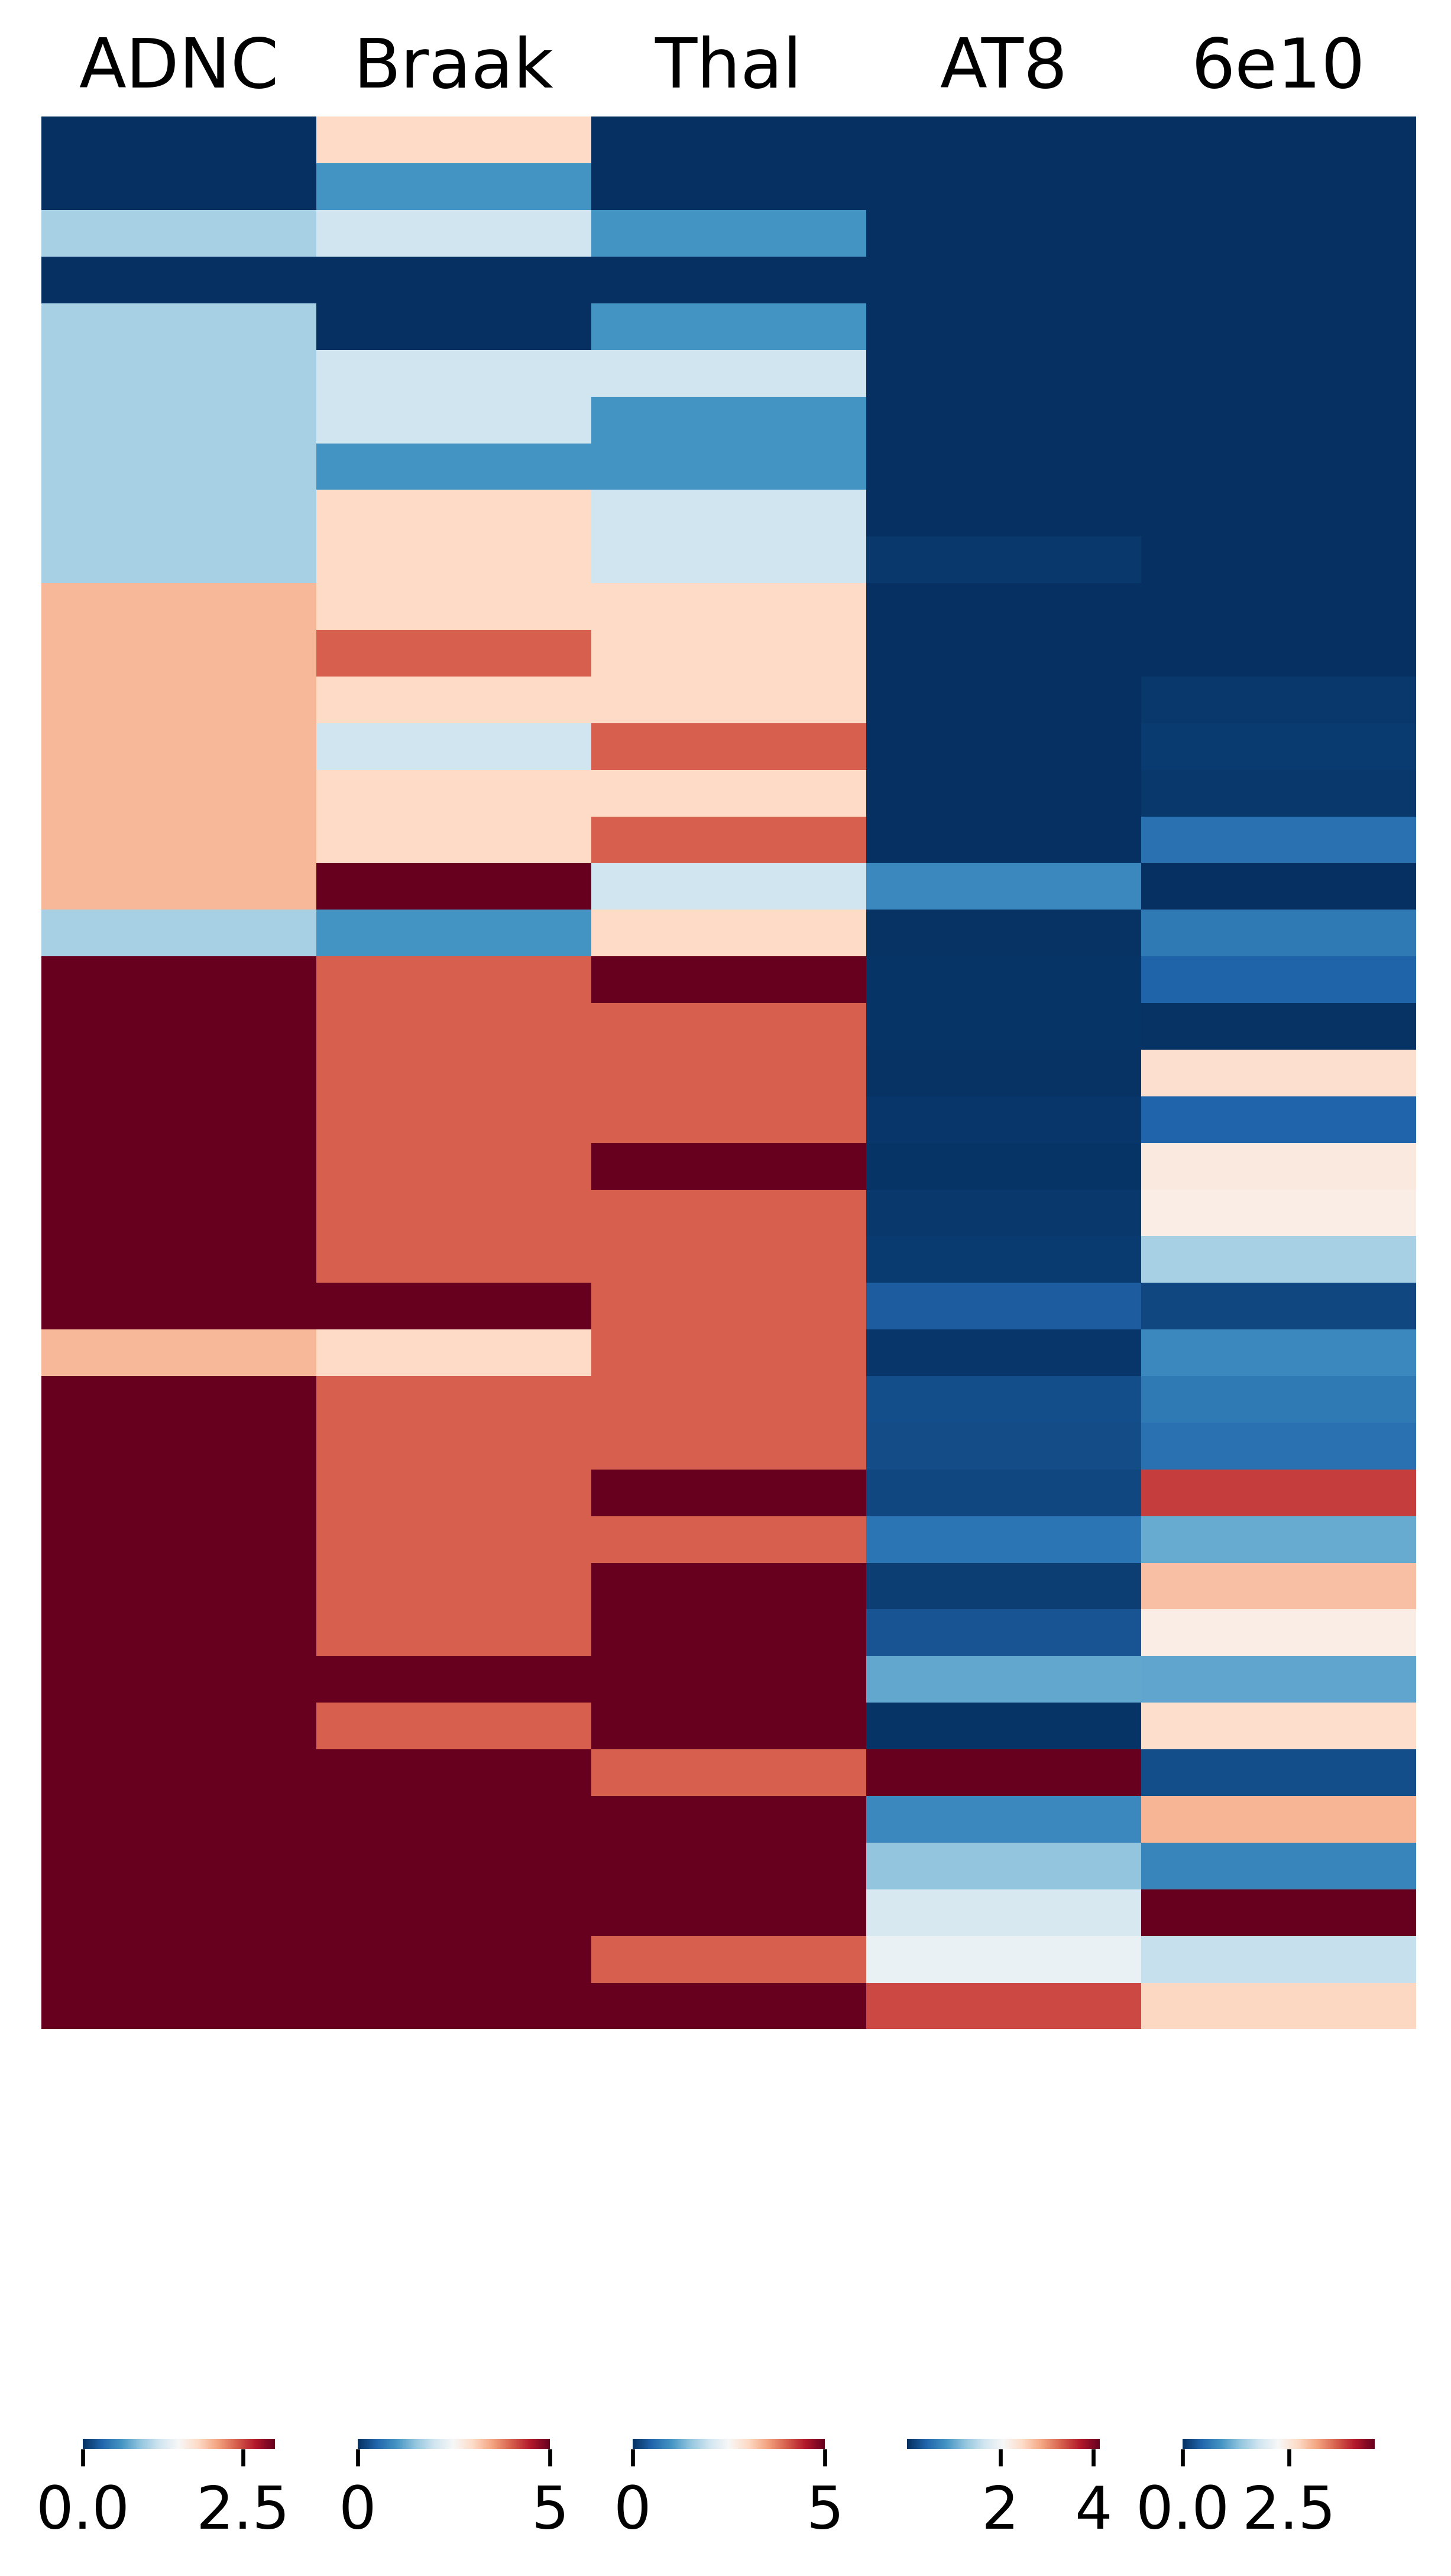

In [27]:
fig, axes = plt.subplots( 1,len(data.columns),  figsize=(5,  10), sharex=True)

for i, col in enumerate(data.columns):
    
    sns.heatmap(data = pd.DataFrame(data[col].cat.codes) if hasattr(data[col], 'cat') else data[[col]], ax=axes[i], cmap='RdBu_r', cbar=True,
                yticklabels=False, xticklabels = False,  cbar_kws={"shrink": 0.7, "orientation": "horizontal"}, ) # Show y-labels only for the first subplot

    axes[i].set_ylabel('') # Remove default y-axis label
        
    axes[i].set_title(col, fontsize = 14)
    cbar = axes[i].collections[0].colorbar
    cbar.ax.tick_params(labelsize=12)
    plt.subplots_adjust(wspace=0, hspace=0)